<a href="https://colab.research.google.com/github/PabloContrerasA/OASIS-3-Dementia-Severity-Determining-Neural-Network-FNN-/blob/main/Gustavo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [257]:
# Imports

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
%matplotlib inline
from scipy.optimize import curve_fit
from sklearn.model_selection import train_test_split
os.environ["TF_DETERMINISTIC_OPS"] = "1"
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from tensorflow.keras import regularizers
from sklearn.metrics import classification_report

In [258]:
# Setting a seed for reproducible results

# seed = 5

# random.seed(seed)
# np.random.seed(seed)
# tf.random.set_seed(seed)
# os.environ["PYTHONHASHSEED"] = str(seed)

In [259]:
# Download OASIS Datasets

health_history_data = pd.read_csv("OASIS3_UDSa5_health_history.csv")
demographic_data =  pd.read_csv("OASIS3_demographics.csv")
cdr_data = pd.read_csv("OASIS3_UDSb4_cdr.csv")
faq_data = pd.read_csv("OASIS3_UDSb7_faq_fas.csv")
behavior_data = pd.read_csv("OASIS3_UDSb5_npiq.csv")
fs_data = pd.read_csv("OASIS3_Freesurfer_output.csv")
pyschometrics_data = pd.read_csv("OASIS3_UDSc1_cognitive_assessments.csv")


In [260]:
# Take only necessary columns from each dataset

#- - - demographic

demographic_data["hand_binary"] = demographic_data["HAND"].map({"L": 1, "R": 0})
demographic_data = demographic_data.drop(columns=["Subject_accession", "AgeatEntry" ,"race", "ETHNIC", "AIAN", "NHPI","ASIAN", "AA", "WHITE","HAND", "AgeatDeath"])

# - - - cdr

cdr_data = cdr_data[["OASISID","days_to_visit", "MMSE", "CDRTOT"]]



# - - - health history

cols_to_keep = health_history_data.columns[:31]

health_history_data = health_history_data[cols_to_keep]
health_history_data = health_history_data.drop(columns=["PD","PDOTHR","CVPACE", "CBOTHR", "TRAUMBRF", "TRAUMEXT", "TRAUMCHR", "NCOTHR"])

# - - - behavior

behavior_data = behavior_data.drop(columns= "NPIQINF")

# - - - Freesurfer output

# Change "Subject" column to "OASISID" to match others
fs_data = fs_data.rename(columns={"Subject": "OASISID"})

fs_data = fs_data[["OASISID", "IntraCranialVol", "TotalGrayVol", "TOTAL_HIPPOCAMPUS_VOLUME"]]

# - - - pyschometrics

pyschometrics_data = pyschometrics_data[["OASISID", "ANIMALS", "srttotal"]]
# - - - FAQ

faq_cols = ["BILLS", "TAXES", "SHOPPING", "GAMES", "STOVE",
            "MEALPREP", "PAYATTN", "REMDATES", "TRAVEL"]

#  Replace 8 (not applicable) with 0
faq_data[faq_cols] = faq_data[faq_cols].replace(8, 0)


In the behavior data there are two colums for each attribute. The first column explains if it exists and the second column describes the severity. If the problem wasn"t detected, then the second column is automatically set to NaN. This will cause issues in the future when using forward fill. This must be fixed

In [261]:
symptom_pairs = [
    ("DEL", "DELSEV"),
    ("HALL", "HALLSEV"),
    ("AGIT", "AGITSEV"),
    ("DEPD", "DEPDSEV"),
    ("ANX", "ANXSEV"),
    ("ELAT", "ELATSEV"),
    ("APA", "APASEV"),
    ("DISN", "DISNSEV"),
    ("IRR", "IRRSEV"),
    ("MOT", "MOTSEV"),
    ("NITE", "NITESEV"),
    ("APP", "APPSEV")
]

for symptom, severity in symptom_pairs:
   behavior_data.loc[behavior_data[symptom] == 0, severity] = 0

# Now that the severity also inludes severities of 0 for no symptoms, we can remove the symptom columns

behavior_data = behavior_data.drop(columns=[symptom for symptom, severity in symptom_pairs])

In [262]:
#Creates fill_missing_data method
def fill_missing_data(df) :
  id = df["OASISID"]
  df = df.groupby("OASISID").ffill()
  df["OASISID"] = id
  return df

In [263]:
#if data is missing for a subject"s later exam, assume most recently recorded data is still true and fill it in
faq_data = fill_missing_data(faq_data)
cdr_data = fill_missing_data(cdr_data)
health_history_data = fill_missing_data(health_history_data)
behavior_data = fill_missing_data(behavior_data)
fs_data = fill_missing_data(fs_data)
pyschometrics_data =fill_missing_data(pyschometrics_data)

In [264]:
# Some subjects were examined multiple times. Only take their most recent examination.
health_history_data = health_history_data.drop_duplicates(subset="OASISID", keep="last")
faq_data = faq_data.drop_duplicates(subset="OASISID", keep="last")
cdr_data= cdr_data.drop_duplicates(subset="OASISID", keep="last")
behavior_data = behavior_data.drop_duplicates(subset="OASISID", keep="last")
fs_data = fs_data.drop_duplicates(subset="OASISID", keep="last")
pyschometrics_data = pyschometrics_data.drop_duplicates(subset="OASISID", keep="last")

# Remove duplicate data
cols_to_drop = [
    "age at visit",
    "OASIS_session_label"
]

health_history_data = health_history_data.drop(columns="OASIS-session_label", errors="ignore")
cdr_data = cdr_data.drop(columns=cols_to_drop, errors="ignore")
faq_data = faq_data.drop(columns=cols_to_drop, errors="ignore")
behavior_data = behavior_data.drop(columns=cols_to_drop, errors="ignore")
pyschometrics_data = pyschometrics_data.drop(columns=cols_to_drop, errors="ignore")


In [265]:
# Create clinical_data by merging all previous datasets
clinical_data = (
    health_history_data
        .merge(cdr_data, on=["OASISID", "days_to_visit"], how="inner")
        .merge(faq_data, on=["OASISID", "days_to_visit"], how="inner")
        .merge(behavior_data, on=["OASISID", "days_to_visit"], how="inner")
        .merge(pyschometrics_data, on=["OASISID"], how="inner")
        .merge(fs_data, on = ["OASISID"], how = "inner")
        .merge(demographic_data, on="OASISID", how="inner")
)

clinical_data = clinical_data.drop(columns=["OASISID", "OASIS_session_label", "days_to_visit"])

In [266]:
# Keeping all the severity columns may add noise. It may be better to have a one column that sums up its values though it should be noted that doing so assumes all have equal clinical importance

# - - - severity

clinical_data["symptom_severity_total"] = clinical_data[[
    "DELSEV","HALLSEV","AGITSEV","DEPDSEV","ANXSEV","ELATSEV",
    "APASEV","DISNSEV","IRRSEV","MOTSEV","NITESEV","APPSEV"
]].sum(axis=1)

clinical_data = clinical_data.drop(columns=["DELSEV","HALLSEV","AGITSEV","DEPDSEV","ANXSEV","ELATSEV",
    "APASEV","DISNSEV","IRRSEV","MOTSEV","NITESEV","APPSEV"])



In [267]:
# Normalize volume data
clinical_data['hippo_ratio'] = clinical_data['TOTAL_HIPPOCAMPUS_VOLUME'] / clinical_data['IntraCranialVol']
clinical_data['gray_ratio'] = clinical_data['TotalGrayVol'] / clinical_data['IntraCranialVol']


clinical_data = clinical_data.drop(columns=[
    'IntraCranialVol', 'TotalGrayVol', 'TOTAL_HIPPOCAMPUS_VOLUME'
])

In [268]:
# Analyzing clinical_data
print(clinical_data.shape)
print(clinical_data.info())
print(clinical_data.isna().sum())
clinical_data.head()

(1277, 45)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age at visit            1277 non-null   float64
 1   CVHATT                  1272 non-null   float64
 2   CVAFIB                  1272 non-null   float64
 3   CVANGIO                 1271 non-null   float64
 4   CVBYPASS                1272 non-null   float64
 5   CVCHF                   1272 non-null   float64
 6   CVOTHR                  1272 non-null   float64
 7   CBSTROKE                1272 non-null   float64
 8   CBTIA                   1272 non-null   float64
 9   SEIZURES                1272 non-null   float64
 10  HYPERTEN                1271 non-null   float64
 11  HYPERCHO                1271 non-null   float64
 12  DIABETES                1271 non-null   float64
 13  B12DEF                  1270 non-null   float64
 14  THYROID                 1271 

,age at visit,CVHATT,CVAFIB,CVANGIO,CVBYPASS,CVCHF,CVOTHR,CBSTROKE,CBTIA,SEIZURES,...,EDUC,SES,racecode,daddem,momdem,APOE,hand_binary,symptom_severity_total,hippo_ratio,gray_ratio
0,79.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,4.0,5,5.0,1.0,23.0,0.0,0.0,0.005721,0.390483
1,75.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.0,2.0,5,0.0,1.0,34.0,0.0,0.0,0.004568,0.354287
2,74.30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.0,1.0,5,0.0,0.0,33.0,0.0,0.0,0.005582,0.386978
3,70.24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,1.0,5,1.0,1.0,23.0,1.0,0.0,0.005551,0.378204
4,60.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.0,3.0,2,0.0,0.0,33.0,0.0,0.0,0.006090,0.394910


A considerable number of subjects do not have data for variables important variables

In [269]:
clinical_data = clinical_data.dropna()
print(clinical_data.shape)
print(clinical_data.info())
print(clinical_data.isna().sum())
clinical_data.head()

(1155, 45)
<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1276
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age at visit            1155 non-null   float64
 1   CVHATT                  1155 non-null   float64
 2   CVAFIB                  1155 non-null   float64
 3   CVANGIO                 1155 non-null   float64
 4   CVBYPASS                1155 non-null   float64
 5   CVCHF                   1155 non-null   float64
 6   CVOTHR                  1155 non-null   float64
 7   CBSTROKE                1155 non-null   float64
 8   CBTIA                   1155 non-null   float64
 9   SEIZURES                1155 non-null   float64
 10  HYPERTEN                1155 non-null   float64
 11  HYPERCHO                1155 non-null   float64
 12  DIABETES                1155 non-null   float64
 13  B12DEF                  1155 non-null   float64
 14  THYROID                 1155 non-n

,age at visit,CVHATT,CVAFIB,CVANGIO,CVBYPASS,CVCHF,CVOTHR,CBSTROKE,CBTIA,SEIZURES,...,EDUC,SES,racecode,daddem,momdem,APOE,hand_binary,symptom_severity_total,hippo_ratio,gray_ratio
0,79.40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,12.0,4.0,5,5.0,1.0,23.0,0.0,0.0,0.005721,0.390483
1,75.36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.0,2.0,5,0.0,1.0,34.0,0.0,0.0,0.004568,0.354287
2,74.30,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,18.0,1.0,5,0.0,0.0,33.0,0.0,0.0,0.005582,0.386978
3,70.24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,1.0,5,1.0,1.0,23.0,1.0,0.0,0.005551,0.378204
4,60.16,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,16.0,3.0,2,0.0,0.0,33.0,0.0,0.0,0.006090,0.394910


In [270]:
print(clinical_data["CDRTOT"].value_counts())

CDRTOT
0.0    780
0.5    167
2.0     99
1.0     95
3.0     14
Name: count, dtype: int64


In [271]:
# Separate input data that will be used to make the prediction and the target CDR data which is the real diagnosis. Changes categorical data to numeric data. Also removed redundant categories.

x = clinical_data.drop(columns="CDRTOT")
y = clinical_data["CDRTOT"]

# Separates data into training and testing data

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size= 0.2, random_state=seed, stratify = y)

In [272]:
unique_cdr = clinical_data["CDRTOT"].unique()
print(unique_cdr)

[0.  1.  0.5 2.  3. ]


In [273]:
# Creating classes for sparse-categorical-crossentropy

value_to_class = {0: 0, 0.5: 1, 1: 2, 2: 3, 3: 4}
y_train_classes = np.array([value_to_class[y] for y in y_train])
y_test_classes = np.array([value_to_class[y] for y in y_test])

The goal of this project is to predict CDR as accurately as possible without using CDR domains that require CDR evaluations from doctors: memory, orient, judgment, commun, homehobb, and perscare. Doing so successfully would make this neural network a good tool for reaffirming doctor evaluations and prescreenning. Some of the variables within the model correlate to the aforemention CDR domains without requiring a cdr examination. It would be a good idea to create new parameters that describe the relationship between varaibles that relate to the CDR domains to work as "stand ins" for them and make sure the model understands their relationship

In [274]:
# Scaling all variables that will be used to create proxies
from sklearn.preprocessing import MinMaxScaler

# temporarily converting x_train back to a dataframe for the creation of the proxies

all_features = ['age at visit', 'CVHATT', 'CVAFIB', 'CVANGIO', 'CVBYPASS', 'CVCHF', 'CVOTHR','CBSTROKE', 'CBTIA', 'SEIZURES', 'HYPERTEN', 'HYPERCHO', 'DIABETES', 'B12DEF','THYROID',
'INCONTU', 'INCONTF', 'DEP2YRS', 'DEPOTHR', 'ALCOHOL', 'MMSE','BILLS', 'TAXES', 'SHOPPING', 'GAMES', 'STOVE', 'MEALPREP', 'EVENTS', 'PAYATTN', 'REMDATES', 'TRAVEL', 'ANIMALS', 'srttotal', 'GENDER',
'EDUC','SES', 'racecode', 'daddem', 'momdem', 'APOE', 'hand_binary', 'symptom_severity_total', 'hippo_ratio', 'gray_ratio']

x_train = pd.DataFrame(x_train, columns=all_features)

proxy_inputs = ["srttotal","hippo_ratio", "REMDATES", "ANIMALS", "gray_ratio", "BILLS", "TAXES", "SHOPPING", "TRAVEL","GAMES", "STOVE", "MEALPREP"]

scaler_proxy = MinMaxScaler()
x_train[proxy_inputs] = scaler_proxy.fit_transform(x_train[proxy_inputs])
x_test[proxy_inputs] = scaler_proxy.transform(x_test[proxy_inputs])

# - - - memory stand in

x_train["memory_proxy"] = x_train[["srttotal","hippo_ratio", "REMDATES"]].mean(axis=1)
x_test["memory_proxy"] = x_test[["srttotal","hippo_ratio", "REMDATES"]].mean(axis=1)

# - - - no direct orientation stand in

# - - - judgement stand in

x_train["judgment_proxy"] = x_train[["ANIMALS", "gray_ratio"]].mean(axis=1)
x_test["judgment_proxy"] = x_test[["ANIMALS", "gray_ratio"]].mean(axis=1)

# - - - commun stand in

x_train["commun_proxy"] = x_train[["BILLS", "TAXES", "SHOPPING", "TRAVEL"]].mean(axis=1)
x_test["commun_proxy"] = x_test[["BILLS", "TAXES", "SHOPPING", "TRAVEL"]].mean(axis=1)
# - - - homehobb stand in

x_train["homehobb_proxy"] = x_train[["GAMES", "STOVE", "MEALPREP"]].mean(axis=1)
x_test["homehobb_proxy"] = x_test[["GAMES", "STOVE", "MEALPREP"]].mean(axis=1)
# - - - no direct perscare stand in

x_train.drop(columns = proxy_inputs)

x_train.to_numpy()


array([[94.72      ,  0.        ,  0.        , ...,  0.33437242,
         0.5       ,  0.2962963 ],
       [59.75      ,  0.        ,  0.        , ...,  0.50353202,
         0.        ,  0.        ],
       [69.42      ,  0.        ,  0.        , ...,  0.51356879,
         0.        ,  0.        ],
       ...,
       [82.45      ,  0.        ,  0.        , ...,  0.42573429,
         0.11111111,  0.        ],
       [97.47      ,  0.        ,  0.        , ...,  0.31093492,
         0.16666667,  0.11111111],
       [75.25      ,  0.        ,  0.        , ...,  0.40754423,
         0.        ,  0.        ]])

In [275]:
# Seperate Categorical Data so that it isn't scaled
categorical_cols = ['GENDER', 'racecode', 'daddem', 'momdem', 'hand_binary']

# Normalizing data by scaling

numeric_cols = [col for col in x_train.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),  # scale numeric features
        ('cat', 'passthrough', categorical_cols) # leave categorical features as-is
    ]
)

x_train = preprocessor.fit_transform(x_train)
x_test  = preprocessor.transform(x_test)

In [276]:
# Assigns Class Weights

unique, counts = np.unique(y_train_classes, return_counts=True)
class_weight = {i: max(counts)/c for i,c in zip(unique, counts)}

In [277]:
# Neural Network

model = tf.keras.Sequential([
tf.keras.Input(shape=(x_train.shape[1],)),
tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
tf.keras.layers.Dropout(0.2),
tf.keras.layers.Dense(32, activation="relu", kernel_regularizer=regularizers.l2(0.001)),
 tf.keras.layers.Dropout(0.2),
tf.keras.layers.Dense(5, activation="softmax")
])


model.compile( optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])


In [278]:
# Early stopping to prevent overfitting

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience = 5, restore_best_weights=True
)

In [279]:
# Trains

history = model.fit(
    x_train, y_train_classes,
    epochs = 200,
    shuffle = True,
    batch_size=32,
    validation_split = 0.2,
    class_weight=class_weight,
    callbacks=[early_stop]
)

Epoch 1/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.3073 - loss: 5.8365 - val_accuracy: 0.6270 - val_loss: 1.3252
Epoch 2/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5309 - loss: 4.8236 - val_accuracy: 0.7027 - val_loss: 1.1320
Epoch 3/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6073 - loss: 4.2791 - val_accuracy: 0.7243 - val_loss: 0.9370
Epoch 4/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6519 - loss: 3.7652 - val_accuracy: 0.7351 - val_loss: 0.8115
Epoch 5/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7041 - loss: 3.4720 - val_accuracy: 0.7351 - val_loss: 0.7696
Epoch 6/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6821 - loss: 3.1744 - val_accuracy: 0.7568 - val_loss: 0.7043
Epoch 7/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7088 - loss: 3.2928 - val_accuracy: 0.7568 - val_loss: 0.7164
Epoch 8/200
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6901 - loss: 2.9552 - val_accuracy: 0.7676 - 

In [280]:
y_pred = model.predict(x_test).argmax(axis=1)
print(classification_report(y_test_classes, y_pred))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

           0       0.97      0.92      0.95       156
           1       0.65      0.73      0.69        33
           2       0.63      0.63      0.63        19
           3       0.68      0.85      0.76        20
           4       0.50      0.33      0.40         3

    accuracy                           0.86       231
   macro avg       0.69      0.69      0.68       231
weighted avg       0.87      0.86      0.86       231



In [281]:
model.evaluate(x_test,y_test_classes)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8456 - loss: 0.5420 


[0.5228812098503113, 0.8571428656578064]

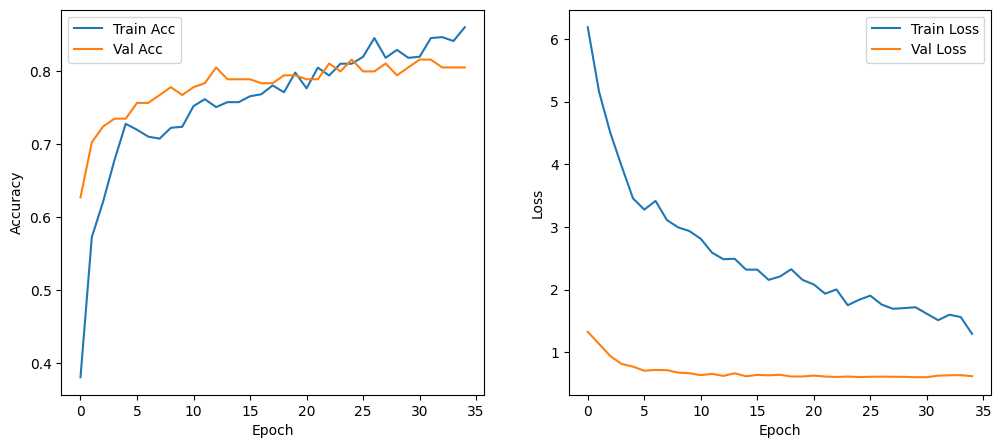

In [282]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

a (initial scale): 1.0311
b (decay rate): 0.3777
c (asymptotic loss): 0.6204


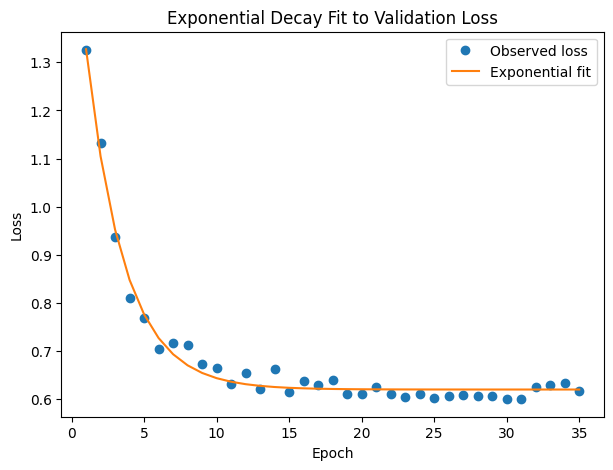

In [283]:
loss = np.array(history.history["val_loss"])

epochs = np.arange(1, len(loss) + 1)


def exp_decay(t, a, b, c):
    return a * np.exp(-b * t) + c


initial_guess = [loss[0], 0.1, loss[-1]]


params, covariance = curve_fit(
    exp_decay,
    epochs,
    loss,
    p0=initial_guess,
    maxfev=10000
)

a, b, c = params

print(f"a (initial scale): {a:.4f}")
print(f"b (decay rate): {b:.4f}")
print(f"c (asymptotic loss): {c:.4f}")

fitted_loss = exp_decay(epochs, a, b, c)

plt.figure(figsize=(7,5))
plt.plot(epochs, loss, "o", label="Observed loss")
plt.plot(epochs, fitted_loss, "-", label="Exponential fit")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Exponential Decay Fit to Validation Loss")
plt.show()

In [284]:
ss_res = np.sum((loss - fitted_loss) ** 2)
ss_tot = np.sum((loss - np.mean(loss)) ** 2)

r_squared = 1 - (ss_res / ss_tot)

print(f"R^2 of exponential fit: {r_squared:.4f}")

R^2 of exponential fit: 0.9859
